## Signal Processing Pipeline

In [16]:
FILE_NAME = "Datasets/Raw/ARNAV_02_20260504_163704.npz"

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from brainflow.data_filter import DataFilter, NoiseTypes, FilterTypes

data = np.load(FILE_NAME)
X = data['X_csp']
y = data['y']

### 1. RAW EEG Visualization Channel 4

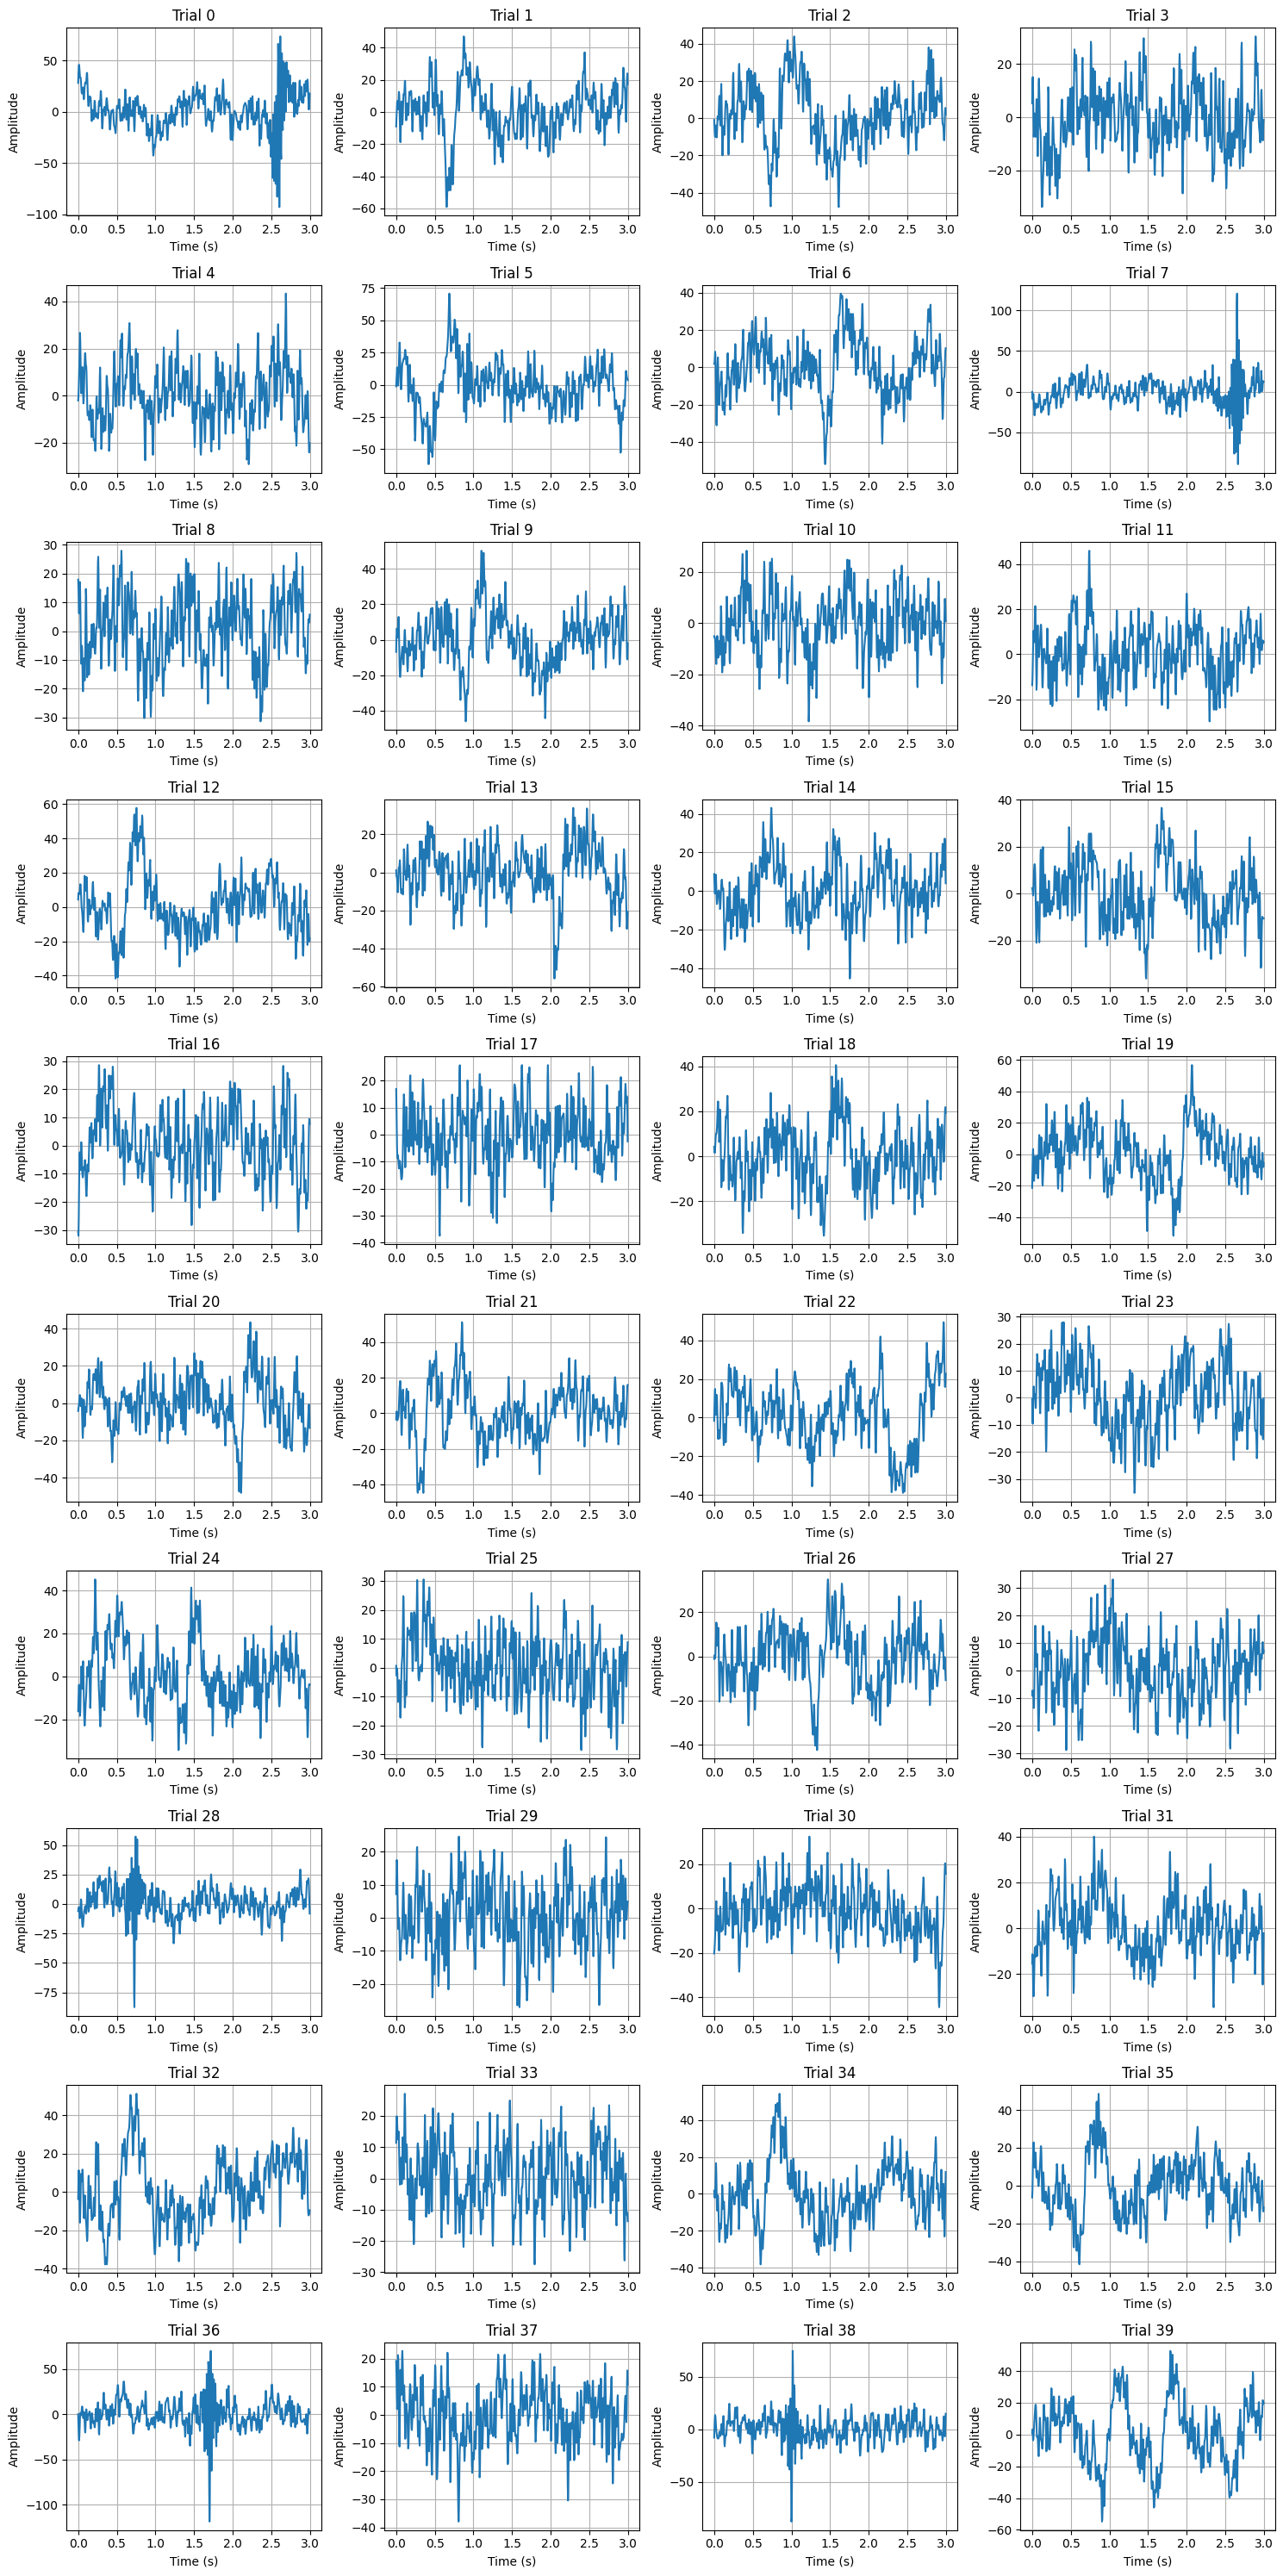

In [18]:
# Multi Plot all trials of channel 4

FS = 250
ch = 5  # channel 4 (0-indexed)

n_trials, _, n_samples = X.shape
t = np.arange(n_samples) / FS

# Choose layout (auto grid)
cols = 4
rows = int(np.ceil(n_trials / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten()

for i in range(n_trials):
    axes[i].plot(t, X[i, ch])
    axes[i].set_title(f"Trial {i}")
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(True)

# Remove unused subplots
for j in range(n_trials, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 2. Z Score Peak Rejection

Good: 39 | Bad: 1


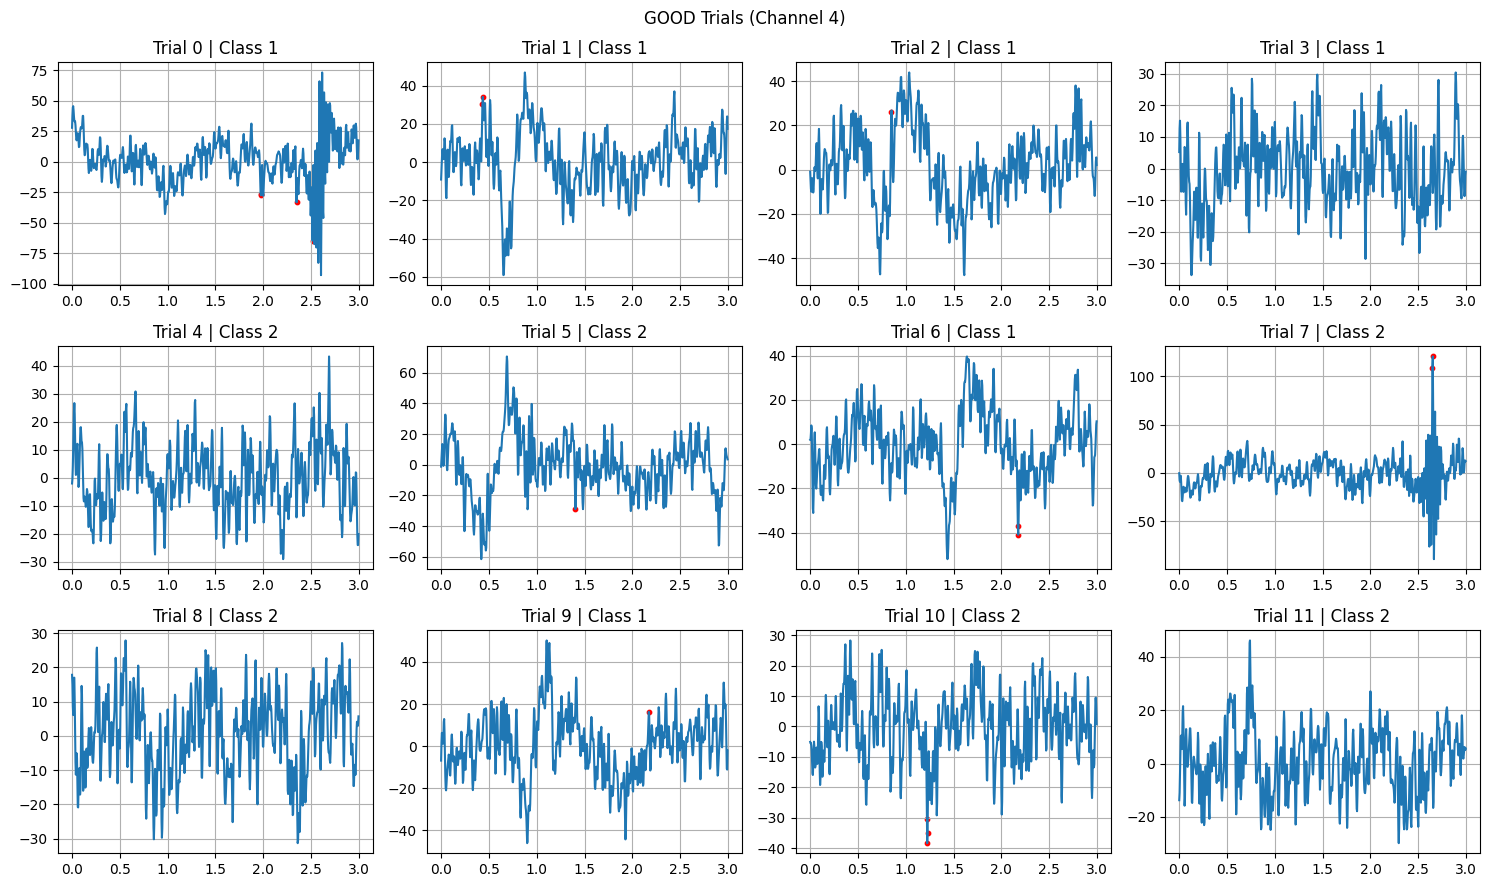

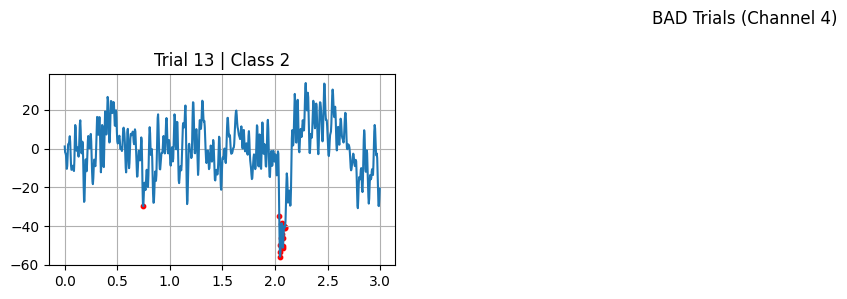

In [19]:
FS = 250
ch = 5

t = np.arange(X.shape[2]) / FS

good_trials = []
bad_trials = []
peak_dict = {}

max_amp_thresh = 200

# --- Detect peaks + classify trials ---
for i in range(X.shape[0]):
    sig = X[i, ch]

    peaks = DataFilter.detect_peaks_z_score(
        sig,
        lag=50,
        threshold=4.0,
        influence=0.0
    )

    peak_idx = np.where(peaks != 0)[0]
    peak_dict[i] = peak_idx

    spike_count = len(peak_idx)
    max_amp = np.max(np.abs(sig))

    # --- Combined rejection rule ---
    if spike_count > 5 or max_amp > max_amp_thresh:
        bad_trials.append(i)
    else:
        good_trials.append(i)

print(f"Good: {len(good_trials)} | Bad: {len(bad_trials)}")


# ---------- FUNCTION TO PLOT ----------
def plot_trials(trial_indices, title):
    cols = 4
    rows = int(np.ceil(len(trial_indices) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for k, i in enumerate(trial_indices):
        sig = X[i, ch]
        peaks = peak_dict[i]

        axes[k].plot(t, sig)

        # mark peaks
        axes[k].scatter(
            t[peaks],
            sig[peaks],
            color='red',
            s=10
        )

        axes[k].set_title(f"Trial {i} | Class {y[i]}")
        axes[k].grid(True)

    # remove unused
    for j in range(len(trial_indices), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# ---------- PLOT ----------
plot_trials(good_trials[:12], "GOOD Trials (Channel 4)")
plot_trials(bad_trials[:12], "BAD Trials (Channel 4)")

In [20]:
FS = 250
ch = 5

spike_thresh = 20
amp_thresh = 200

good_trials = []

for i in range(X.shape[0]):
    sig = X[i, ch]

    peaks = DataFilter.detect_peaks_z_score(
        sig,
        lag=50,
        threshold=4.0,
        influence=0.0
    )

    spike_count = np.sum(peaks != 0)
    max_amp = np.max(np.abs(sig))

    if spike_count <= spike_thresh and max_amp <= amp_thresh:
        good_trials.append(i)

good_trials = np.array(good_trials)

X = X[good_trials]
y = y[good_trials]

print("Kept trial indices:", good_trials)
print("New X shape:", X.shape)
print("New y shape:", y.shape)

Kept trial indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
New X shape: (40, 8, 750)
New y shape: (40,)


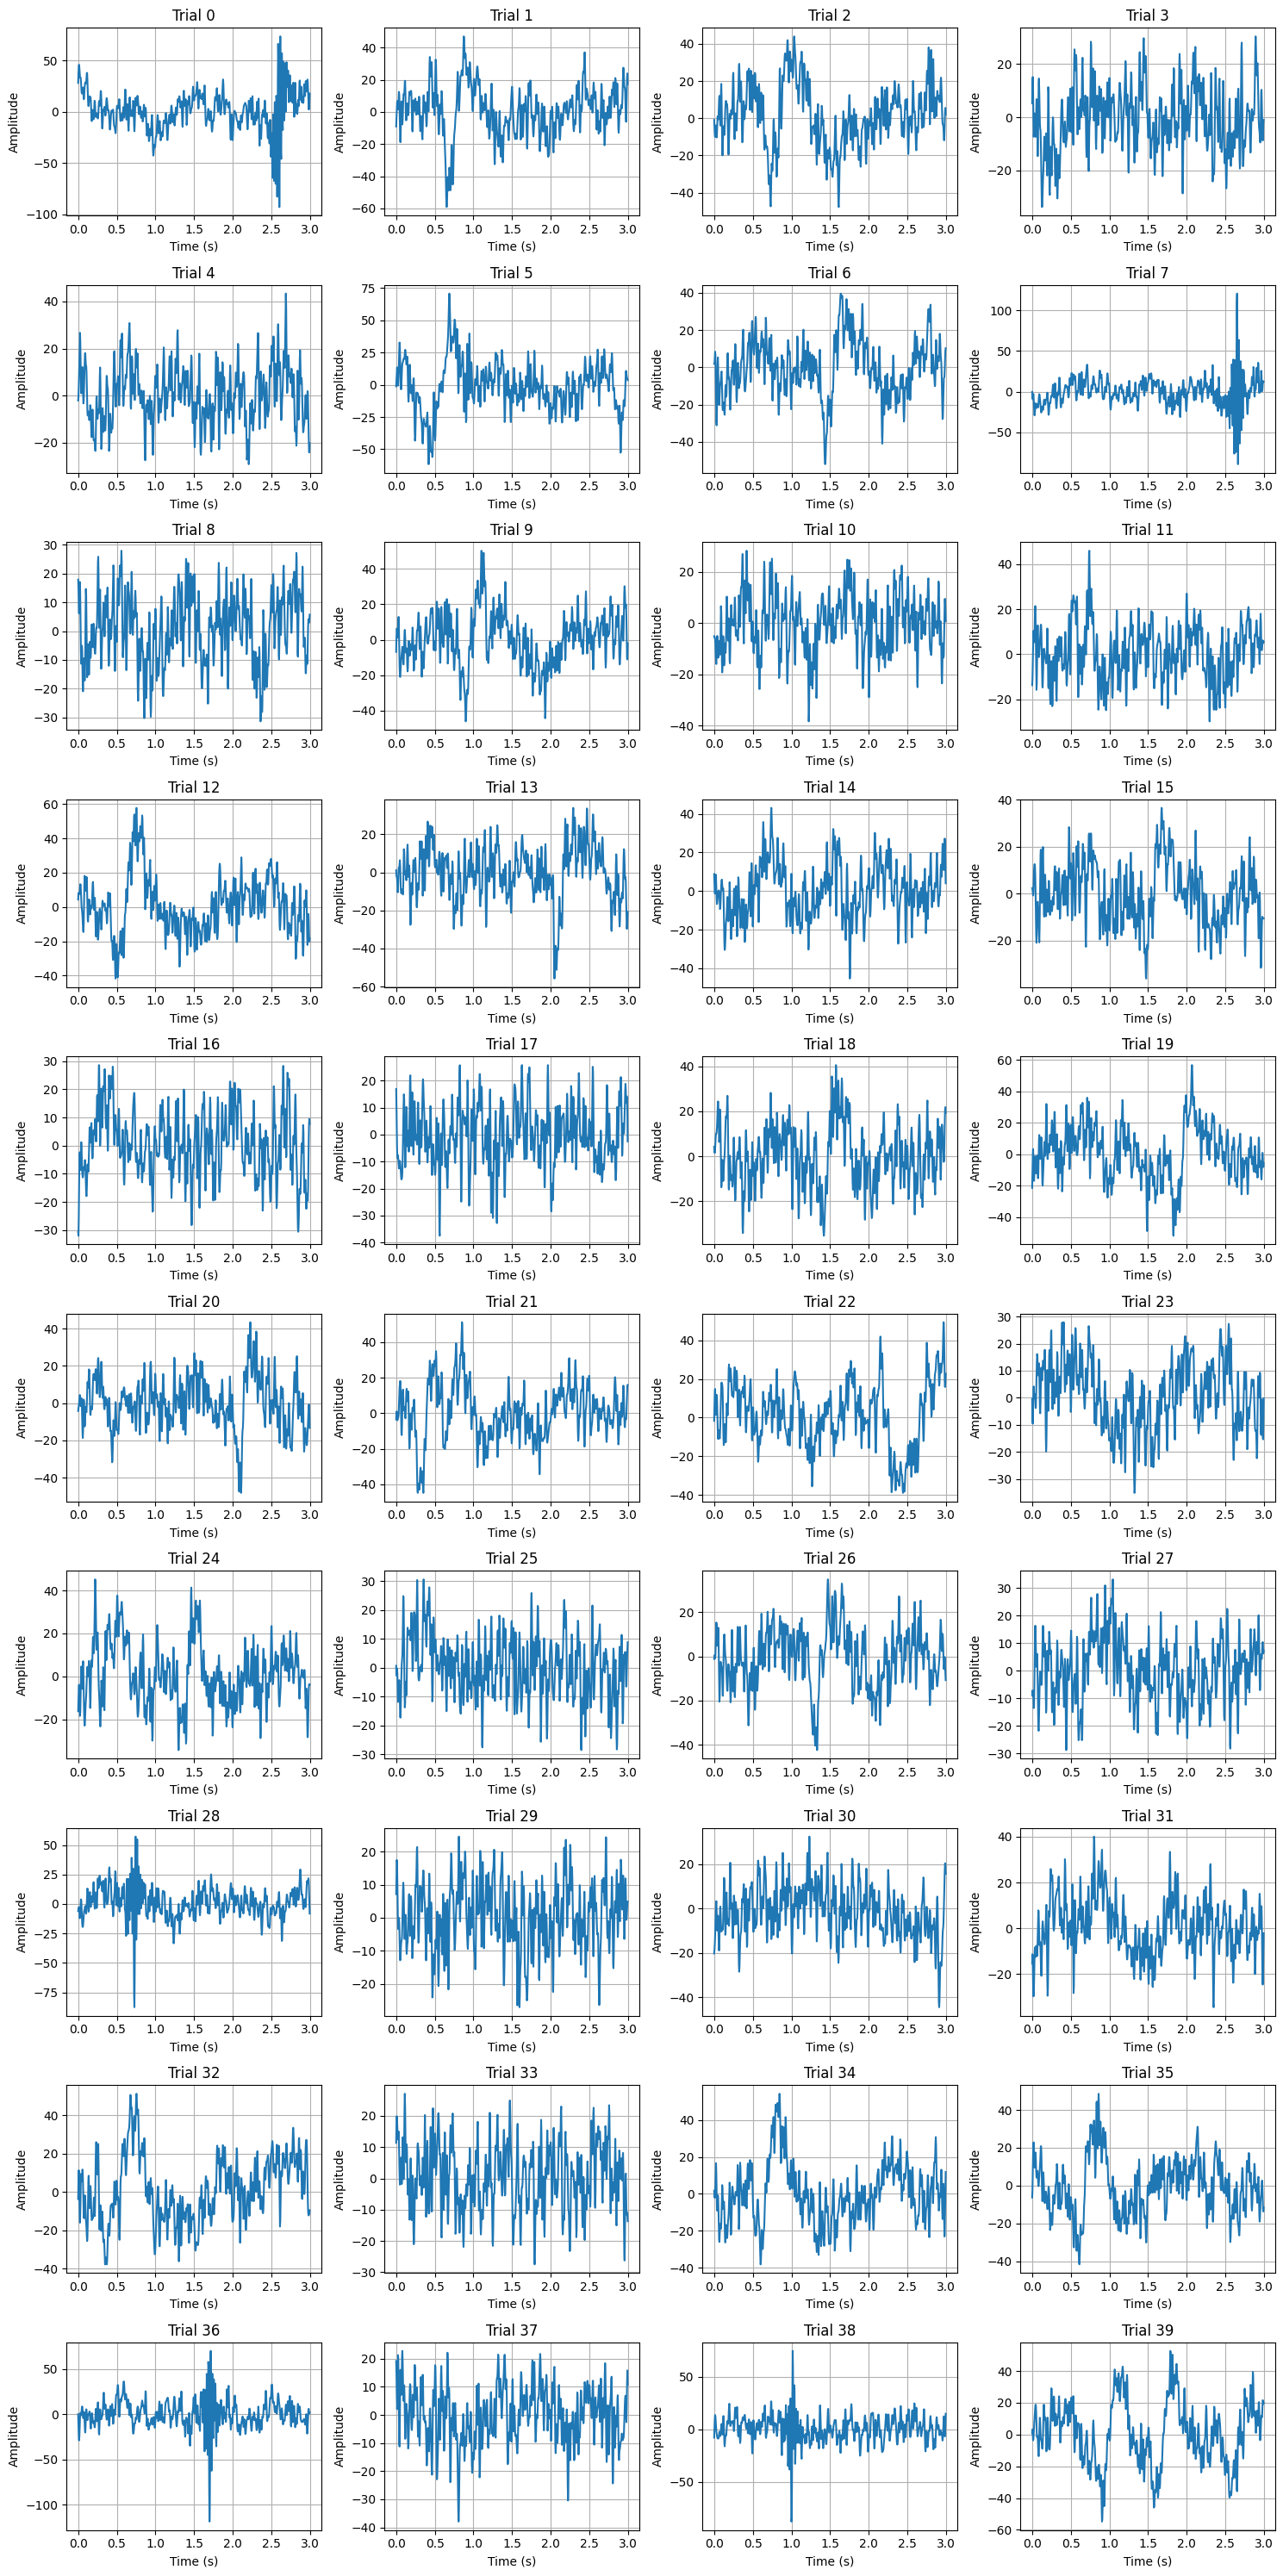

In [21]:
FS = 250
ch = 5  # channel 4 (0-indexed)

n_trials, _, n_samples = X.shape
t = np.arange(n_samples) / FS

# Choose layout (auto grid)
cols = 4
rows = int(np.ceil(n_trials / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten()

for i in range(n_trials):
    axes[i].plot(t, X[i, ch])
    axes[i].set_title(f"Trial {i}")
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(True)

# Remove unused subplots
for j in range(n_trials, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 3. Band Pass 8 - 30 Hz

In [22]:
FS = 250

X_mu = X.copy()

for trial in range(X_mu.shape[0]):
    for ch in range(X_mu.shape[1]):
        DataFilter.perform_bandpass(
            X_mu[trial, ch],
            FS,
            8.0,   # start freq
            30.0,  # stop freq
            4,     # order
            FilterTypes.BUTTERWORTH.value,
            0      
        )

print("Done bandpass 8 - 13 Hz")
X = X_mu

Done bandpass 8 - 13 Hz


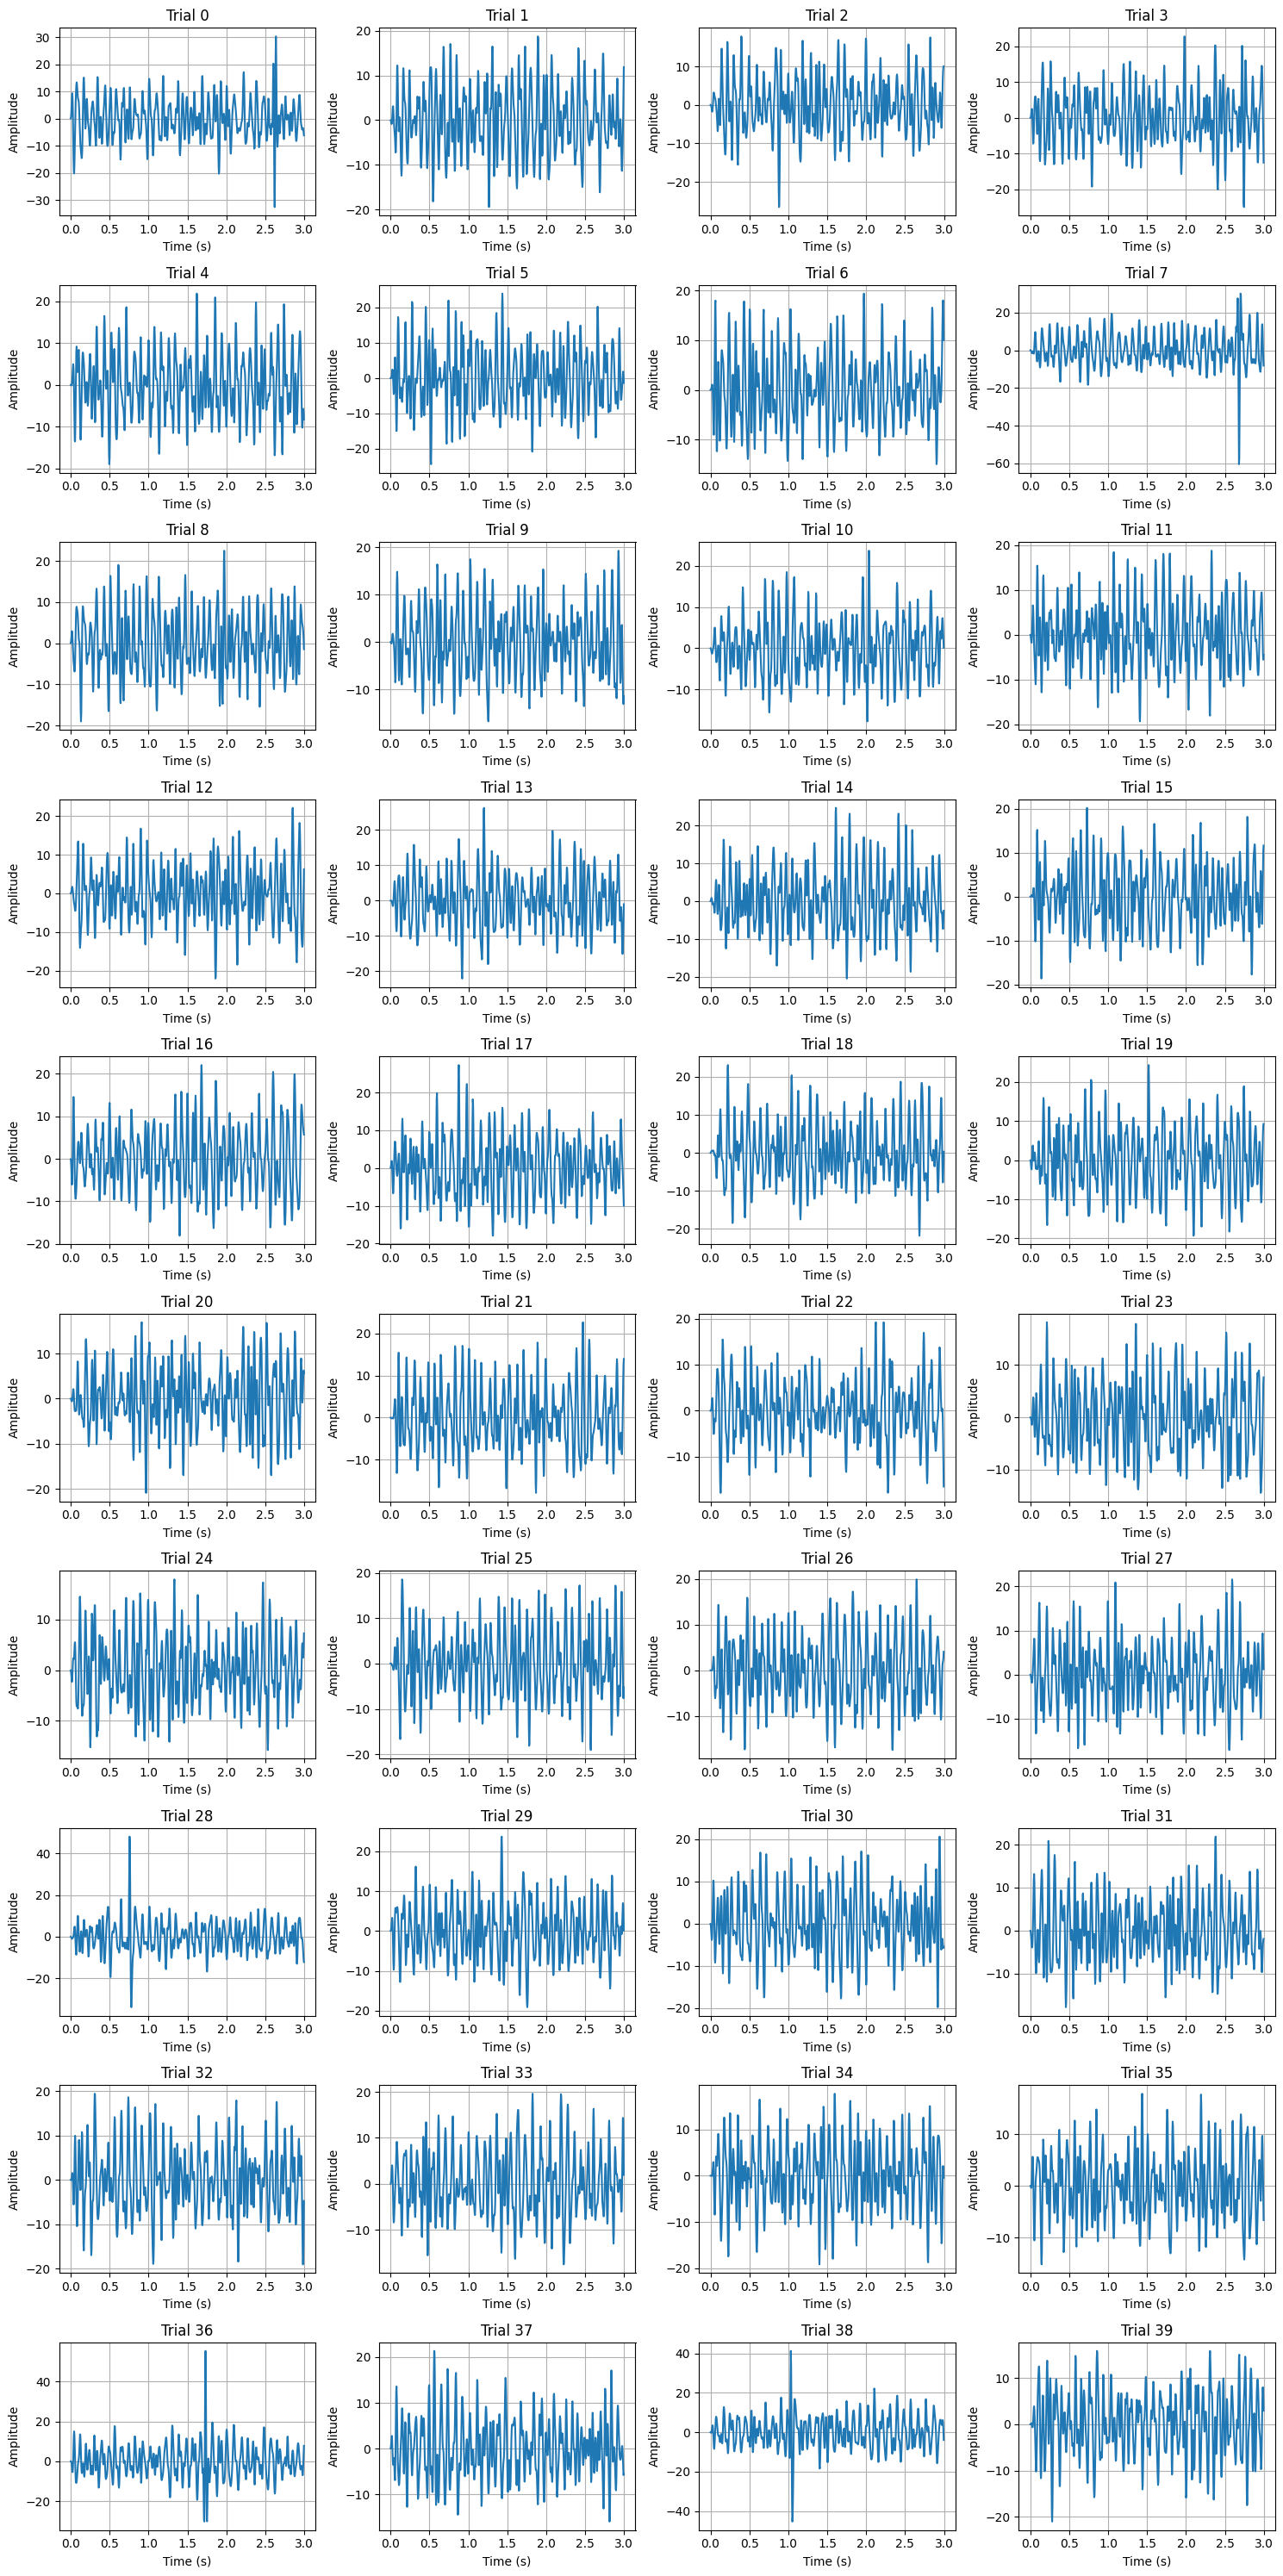

In [23]:
FS = 250
ch = 5  # channel 4 (0-indexed)

n_trials, _, n_samples = X.shape
t = np.arange(n_samples) / FS

# Choose layout (auto grid)
cols = 4
rows = int(np.ceil(n_trials / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten()

for i in range(n_trials):
    axes[i].plot(t, X[i, ch])
    axes[i].set_title(f"Trial {i}")
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(True)

# Remove unused subplots
for j in range(n_trials, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

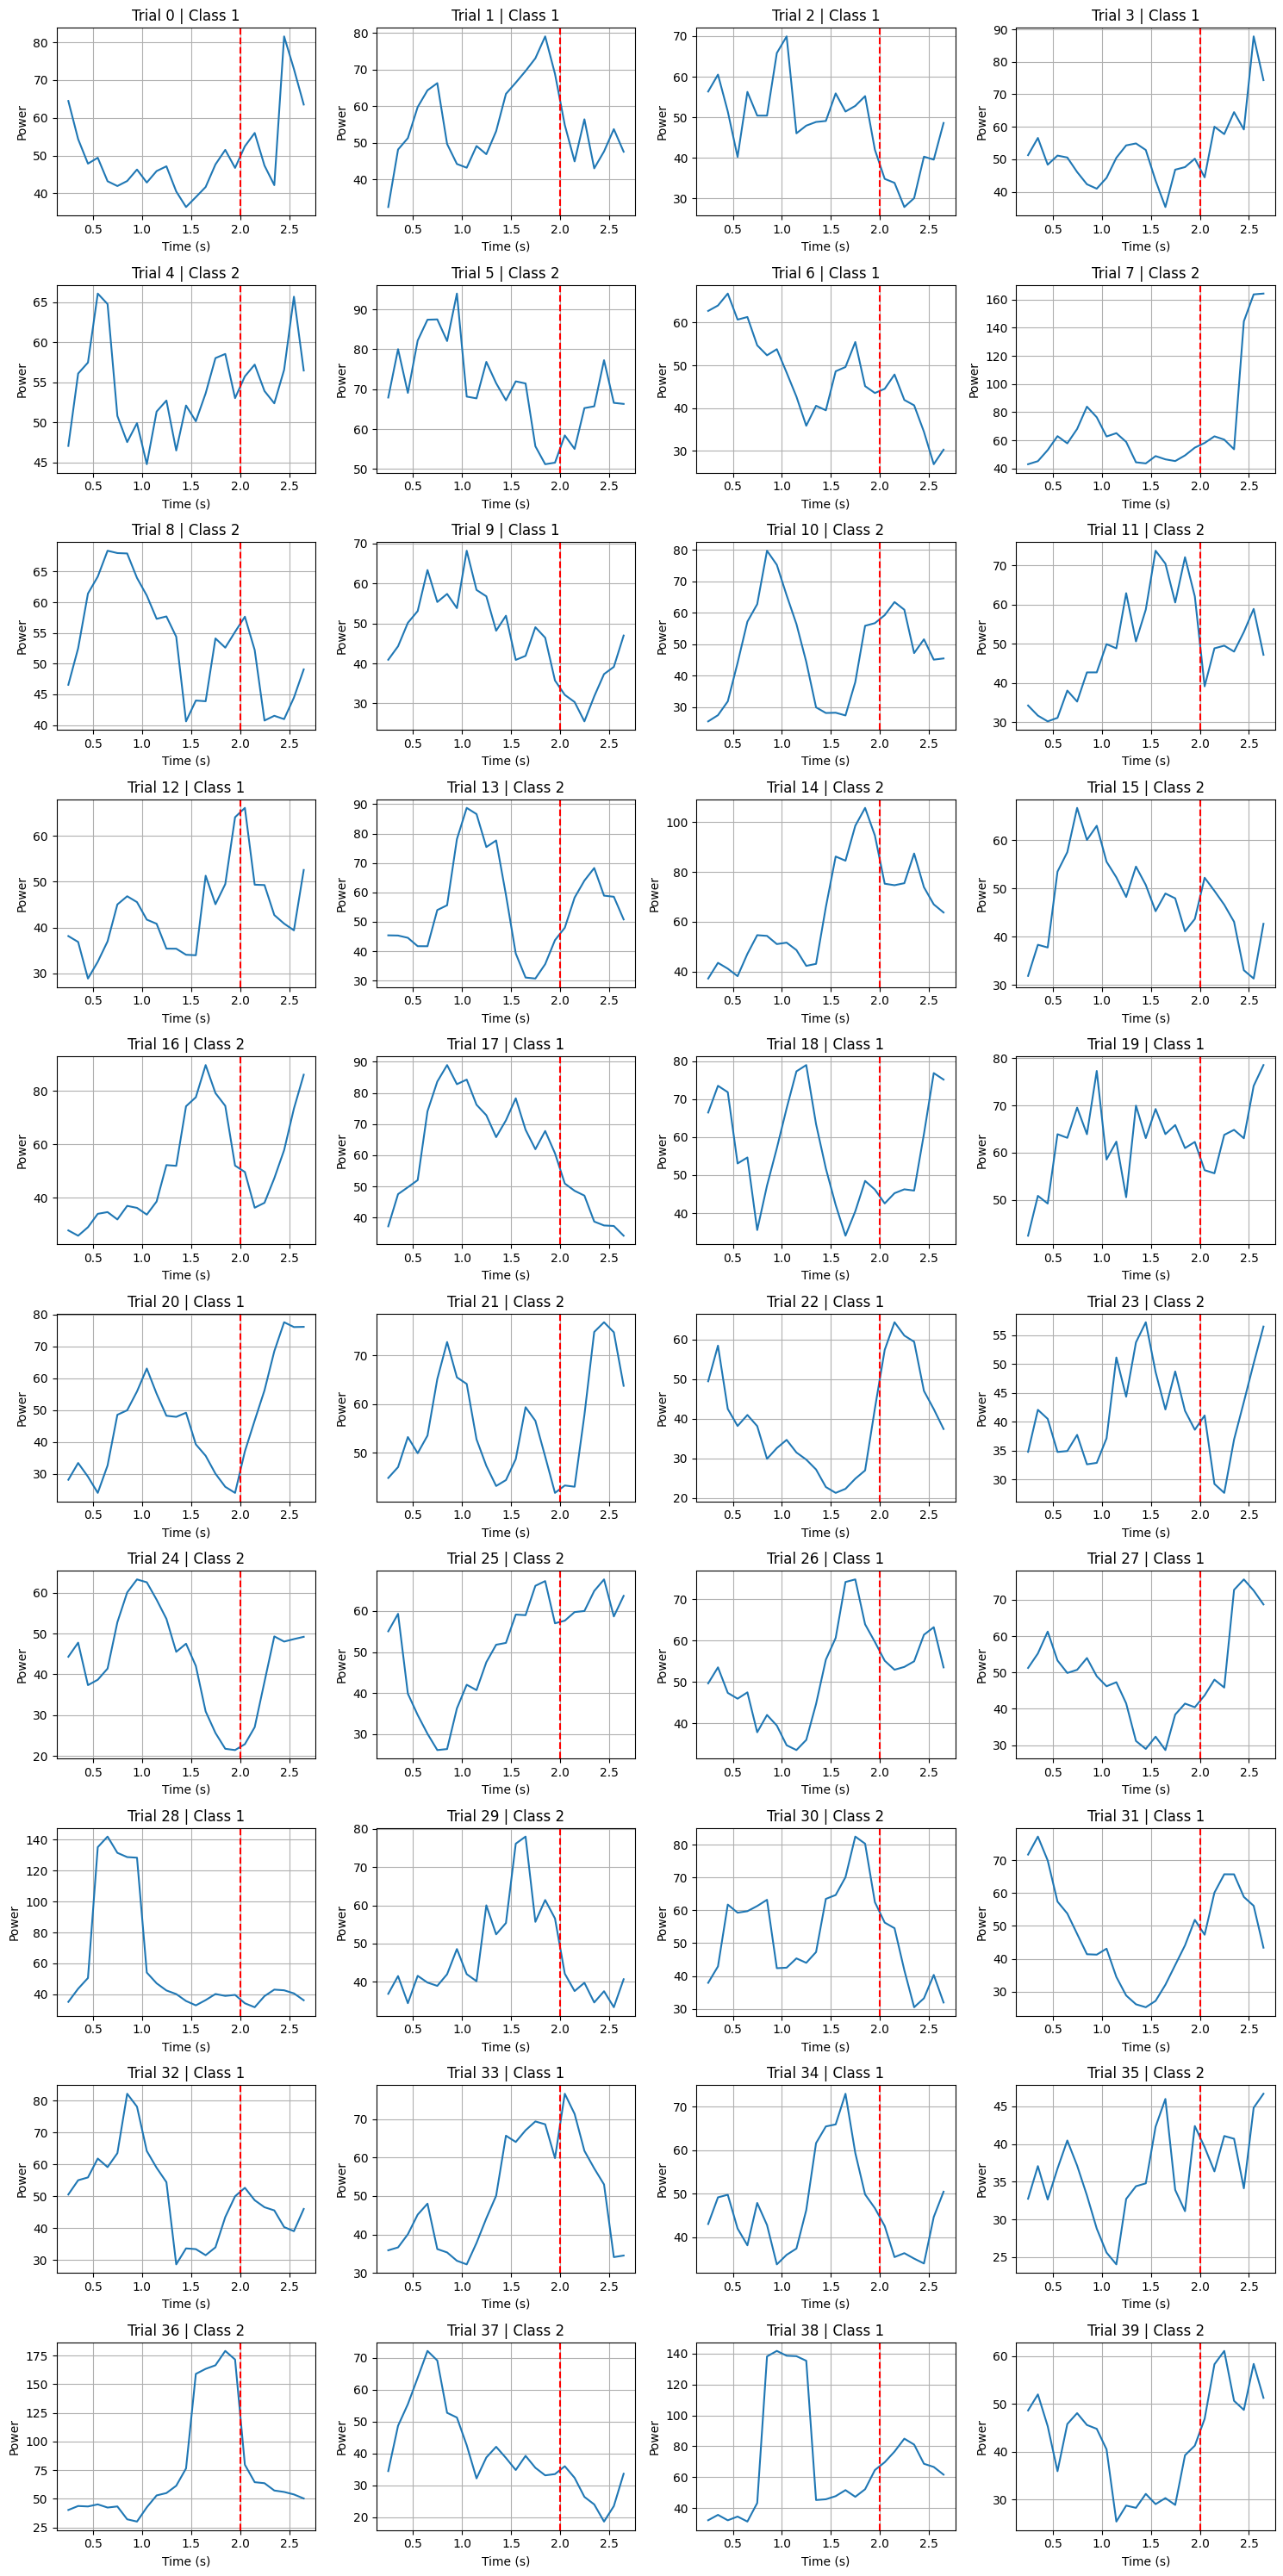

In [24]:
FS = 250
ch = 5

window_size = int(0.5 * FS)   # 0.5 sec
step = int(0.1 * FS)          # 100 ms

def compute_power(sig):
    return np.mean(sig ** 2)

n_trials = X_mu.shape[0]

cols = 4
rows = int(np.ceil(n_trials / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = np.array(axes).reshape(-1)

for i in range(n_trials):
    sig = X_mu[i, ch]

    power_vals = []
    times = []

    for start in range(0, len(sig) - window_size, step):
        window = sig[start:start + window_size]
        power_vals.append(compute_power(window))
        times.append((start + window_size//2) / FS)

    axes[i].plot(times, power_vals)
    axes[i].set_title(f"Trial {i} | Class {y[i]}")
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel("Power")
    axes[i].grid(True)

    # OPTIONAL: mark task start (adjust if needed)
    task_start = 2.0
    axes[i].axvline(task_start, color='red', linestyle='--')

# remove unused plots
for j in range(n_trials, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()